In [1]:
def PVA(pmt, years, interest, belka = False):
    if(interest == 0):
        return pmt * years
    fva = pmt  *  ( (1 - (1 + interest) ** (-1 *years))  / interest)
    b = 0
    if(belka):
        b = (fva - pmt * years) * 0.19
    return fva - b

In [43]:
class Bond():
    def __init__(self, par_value, coupon_rate, n_payments, market_rate=-1, PV=-1):
        self.par_value = par_value
        self.coupon_rate = coupon_rate
        self.n_payments = n_payments
        self.market_rate = market_rate
        self.PV = PV

    @staticmethod
    def PVA(pmt, years, interest, belka = False):
        if(interest == 0):
            return pmt * years
        fva = pmt  *  ( (1 - (1 + interest) ** (-1 *years))  / interest)
        b = 0
        if(belka):
            b = (fva - pmt * years) * 0.19
        return fva - b
    
    def PV_Bond(self):
        assert self.market_rate != -1
        coupon_payment = self.par_value * self.coupon_rate #jednorazowa płatność kuponu
        pv_coupons = PVA(coupon_payment, self.n_payments, self.market_rate) #zdiscountowane kupony (ich npv)
        pv_face_value = self.par_value / (1 + self.market_rate) ** self.n_payments #zdiscountowana wartość nominalna
        return pv_coupons + pv_face_value
    @staticmethod
    def PVB(par_value, coupon_rate, n_payments, market_rate):
        #assert market_rate != -1
        coupon_payment = par_value * coupon_rate #jednorazowa płatność kuponu
        pv_coupons = PVA(coupon_payment, n_payments, market_rate) #zdiscountowane kupony (ich npv)
        pv_face_value = par_value / (1 + market_rate) ** n_payments #zdiscountowana wartość nominalna
        return pv_coupons + pv_face_value
    
    def YTMsimplified(self):
        k = (self.PV - self.par_value )/ self.par_value
        numerator = self.coupon_rate - k/self.n_payments
        denominator = 1 + k * (self.n_payments+1)/ (self.n_payments * 2)
        return numerator/denominator

    def YTMseller(self):
        k = (self.PV - self.par_value )/ self.par_value
        numerator = self.coupon_rate - k/self.n_payments
        denominator = 1 + k * 0.5
        return numerator/denominator
    
    def YTMaccurate(self):
        l = 0
        h = 10
        for i in range(100):
            mid = (l + h)/2
            l_ytm = self.PVB(self.par_value, self.coupon_rate, self.n_payments, l) - self.PV
            mid_ytm = self.PVB(self.par_value, self.coupon_rate, self.n_payments, mid) - self.PV
            
            if(l_ytm * mid_ytm > 0 ):
                l = mid
            else:
                h = mid
        print(mid)
        return mid    

In [2]:
def PV_Bond(par_value, coupon_rate, years, market_rate):
    coupon_payment = par_value * coupon_rate #jednorazowa płatność kuponu
    pv_coupons = PVA(coupon_payment, years, market_rate) #zdiscountowane kupony (ich npv)
    pv_face_value = par_value / (1 + market_rate) ** years #zdiscountowana wartość nominalna
    return pv_coupons + pv_face_value

In [3]:
#problem 1
par_value = 1000
years = 5
coupon_rate = 0.15
market_rate = 0.12
price = PV_Bond(par_value, coupon_rate, years, market_rate)
price

1108.1432860703503

The par value of the bonds is PLN 10,000. The maturity date is 25 years, and the interest rate - at halfyearly paying coupon and interest capitalization - is 10% on a half-year basis. Calculate the price
(current value) of this bond at 5% (yearly) the bond’s market rate of interest

In [4]:
par_value = 10000
years = 25*2
coupon_rate = 0.1
market_rate = 0.05/2
price = PV_Bond(par_value, coupon_rate, years, market_rate) 
print(price)

31271.733760406736


A bond issued by the enterprise for a period of 5 years with a nominal value of PLN 100 is given. The
current price of the bonds is PLN 98.5, a coupon of 6% and the annual interest payment date. Designate
YTM using the simplified method and the seller's Method. Write down the equation with which you
will get the accurate YTM value

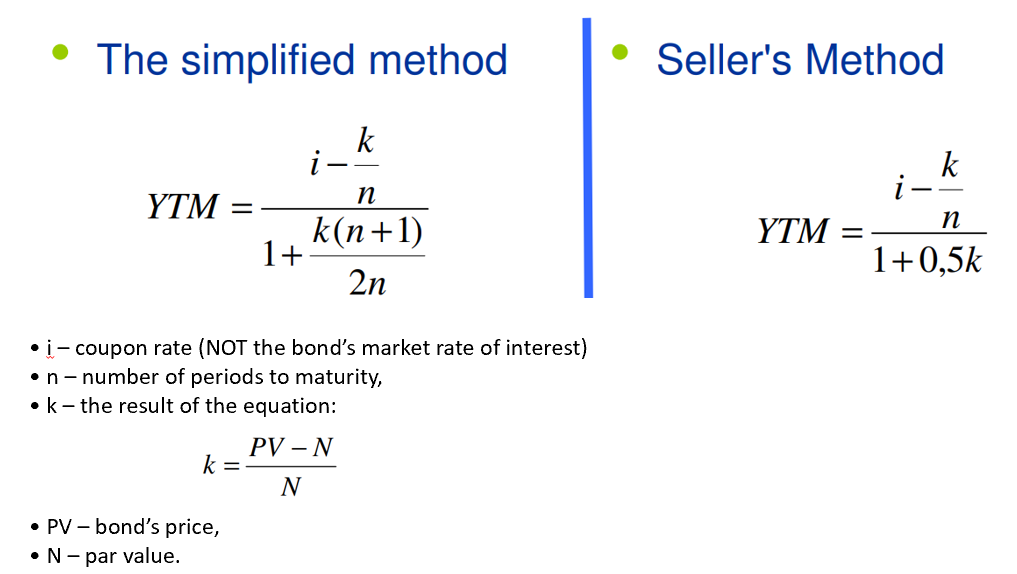

In [6]:
def YTMsimplified(coupon_rate, n_payments, PV, Par):
    k = (PV - Par )/ Par
    numerator = coupon_rate - k/n_payments
    denominator = 1 + k * (n_payments+1)/ (n_payments * 2)
    return numerator/denominator

def YTMseller(coupon_rate, n_payments, PV, Par):
    k = (PV - Par )/ Par
    numerator = coupon_rate - k/n_payments
    denominator = 1 + k * 0.5
    return numerator/denominator

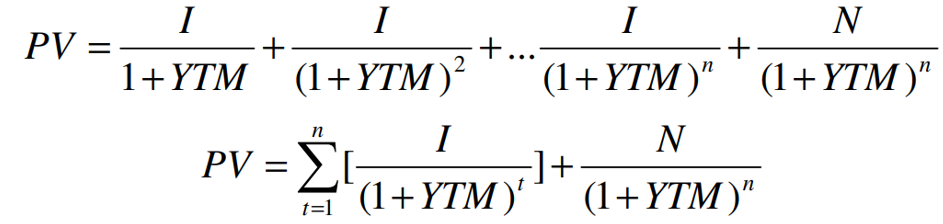

In [11]:
def YTMaccurate(coupon_rate, n_payments, PV, Par):
    l = 0
    h = 10
    for i in range(100):
        mid = (l + h)/2
        l_ytm = PV_Bond(Par, coupon_rate, n_payments, l) - PV
        mid_ytm = PV_Bond(Par, coupon_rate, n_payments, mid) - PV
        
        if(l_ytm * mid_ytm > 0 ):
            l = mid
        else:
            h = mid
    return mid            
        



In [5]:
coupon_rate = 0.06
n_years = 5
PV = 98.5
Par_value = 100

In [7]:
print(YTMsimplified(coupon_rate, n_years, PV, Par_value))

0.06357214934409687


In [8]:
print(YTMseller(coupon_rate, n_years, PV, Par_value))

0.06347607052896725


In [12]:
print(YTMaccurate(coupon_rate, n_years, PV, Par_value))

0.06359585018070837


In [44]:
b = Bond(par_value=par_value, coupon_rate=coupon_rate, n_payments=n_years, PV=PV)

In [45]:
a = b.YTMaccurate()
print(a)

6.124905098786934
6.124905098786934
